In [1]:
# Importing the packages to read and visualize the dataset
 
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns


In [2]:
# Importing the dataset as DataFrame
df = pd.read_csv('data.csv', encoding='latin')

In [3]:
# Top 2 result of the data

df.head(2)

,Player,Span,Mat,Inns,NO,Runs,HS,Ave,BF,SR,100,50,0
0,SR Tendulkar (INDIA),1989-2012,463,452,41,18426,200*,44.83,21367,86.23,49,96,20
1,KC Sangakkara (Asia/ICC/SL),2000-2015,404,380,41,14234,169,41.98,18048,78.86,25,93,15


In [4]:
# Detailed information about the data

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 79 entries, 0 to 78
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Player  79 non-null     object 
 1   Span    79 non-null     object 
 2   Mat     79 non-null     int64  
 3   Inns    79 non-null     int64  
 4   NO      79 non-null     int64  
 5   Runs    79 non-null     int64  
 6   HS      79 non-null     object 
 7   Ave     79 non-null     float64
 8   BF      79 non-null     int64  
 9   SR      79 non-null     float64
 10  100     79 non-null     int64  
 11  50      79 non-null     int64  
 12  0       79 non-null     int64  
dtypes: float64(2), int64(8), object(3)
memory usage: 8.1+ KB


Preprocessing the data to convert all the data to integer format

In [5]:
df.head()

,Player,Span,Mat,Inns,NO,Runs,HS,Ave,BF,SR,100,50,0
0,SR Tendulkar (INDIA),1989-2012,463,452,41,18426,200*,44.83,21367,86.23,49,96,20
1,KC Sangakkara (Asia/ICC/SL),2000-2015,404,380,41,14234,169,41.98,18048,78.86,25,93,15
2,RT Ponting (AUS/ICC),1995-2012,375,365,39,13704,164,42.03,17046,80.39,30,82,20
3,ST Jayasuriya (Asia/SL),1989-2011,445,433,18,13430,189,32.36,14725,91.20,28,68,34
4,DPMD Jayawardene (Asia/SL),1998-2015,448,418,39,12650,144,33.37,16020,78.96,19,77,28


In [6]:
df[['start', 'end']] = df.Span.str.split('-', expand=True)

df.start = df.start.astype('int')
df.end = df.end.astype('int')

In [7]:
df['exp'] = df.end-df.start

In [8]:
df.drop(columns = ['start', 'end', 'Span'], axis=1, inplace=True)

In [9]:
df.HS.unique()

array(['200*', '169', '164', '189', '144', '137*', '139', '183', '153',
       '161*', '141*', '172', '183*', '153*', '162*', '145', '215', '194',
       '150', '152*', '132*', '173', '219', '175', '124', '134*', '130',
       '120*', '131*', '119*', '159', '102', '145*', '141', '108*',
       '188*', '143', '189*', '142*', '139*', '127*', '122', '174*',
       '181*', '166', '121', '140*', '124*', '113*', '185*', '154',
       '116*', '112', '237*', '109*', '264', '119', '144*', '150*',
       '133*', '96*', '156'], dtype=object)

In [10]:
# Creating an strike column to store the result of batsman status

df['strike'] = df.HS.apply(lambda x: 1 if x[-1] == '*' else 0)

In [11]:
# Removing the * from the HS and converting it into integer

df.HS = df.HS.apply(lambda x: int(x.replace('*', '')))

In [12]:
# Information about the data after pre processing

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 79 entries, 0 to 78
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Player  79 non-null     object 
 1   Mat     79 non-null     int64  
 2   Inns    79 non-null     int64  
 3   NO      79 non-null     int64  
 4   Runs    79 non-null     int64  
 5   HS      79 non-null     int64  
 6   Ave     79 non-null     float64
 7   BF      79 non-null     int64  
 8   SR      79 non-null     float64
 9   100     79 non-null     int64  
 10  50      79 non-null     int64  
 11  0       79 non-null     int64  
 12  exp     79 non-null     int32  
 13  strike  79 non-null     int64  
dtypes: float64(2), int32(1), int64(10), object(1)
memory usage: 8.5+ KB


In [13]:
# Check for null values

df.isnull().sum().sum()

0

In [14]:
# Check for the duplications

df.duplicated().sum()

0

In [15]:
# Creating an new DataFrame to do outlier treatment and training an mmodel by removing object from the existing data frame

df_copy = df.drop('Player', axis=1)

In [16]:
df_copy.head(2)

,Mat,Inns,NO,Runs,HS,Ave,BF,SR,100,50,0,exp,strike
0,463,452,41,18426,200,44.83,21367,86.23,49,96,20,23,1
1,404,380,41,14234,169,41.98,18048,78.86,25,93,15,15,0


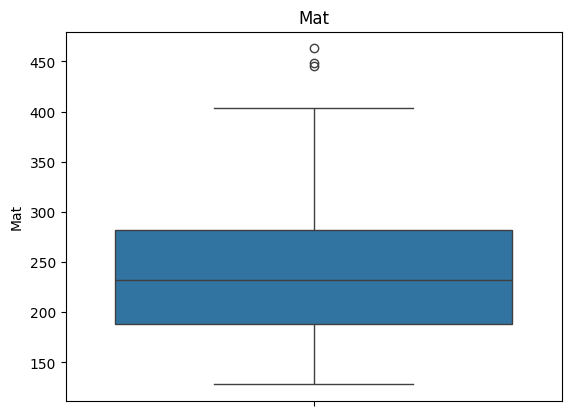

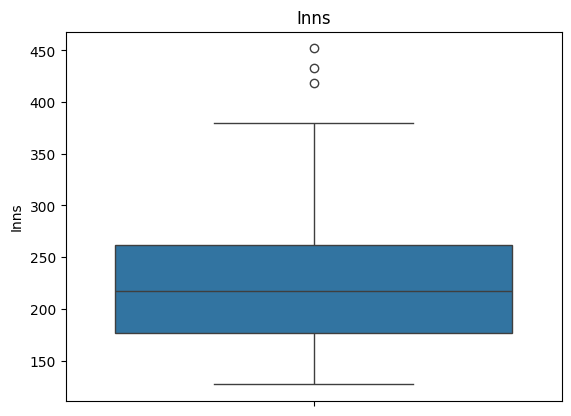

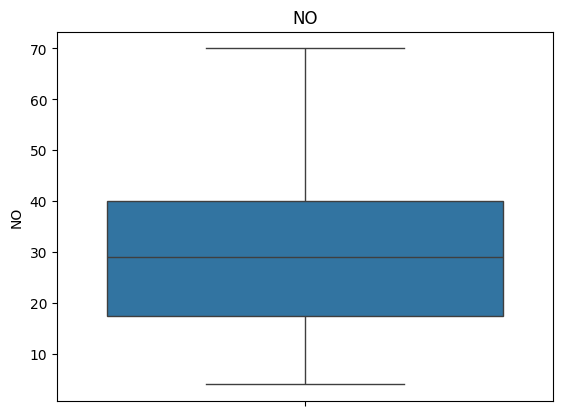

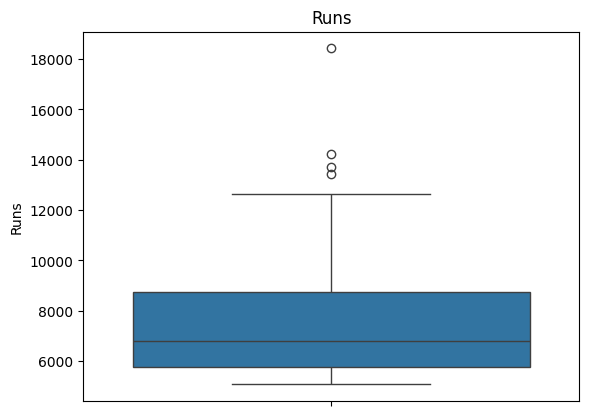

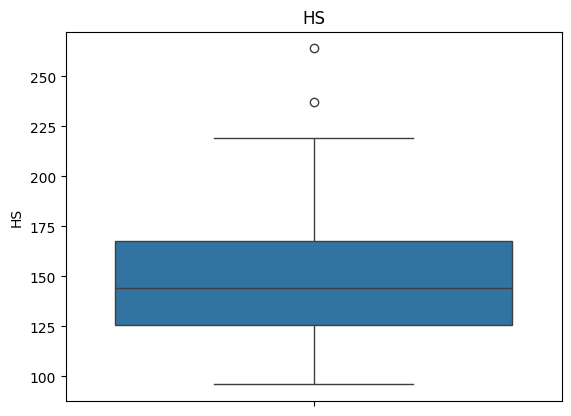

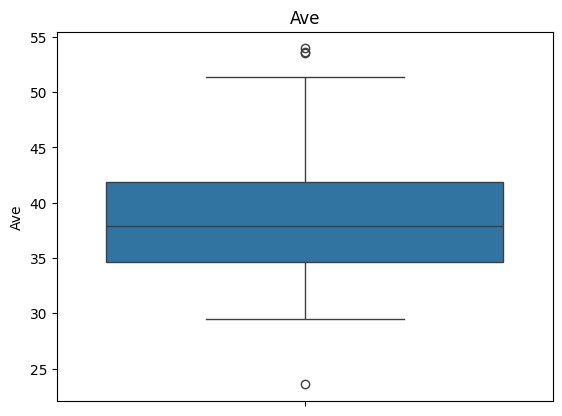

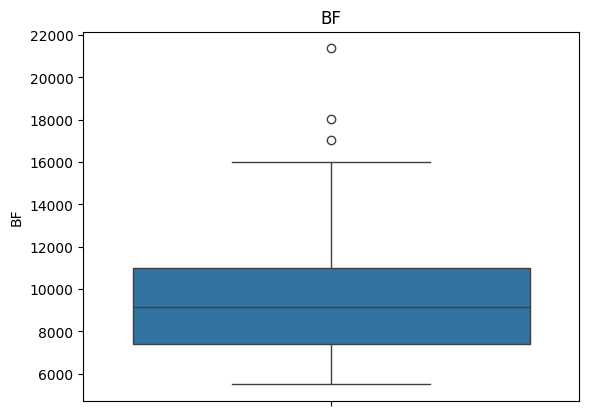

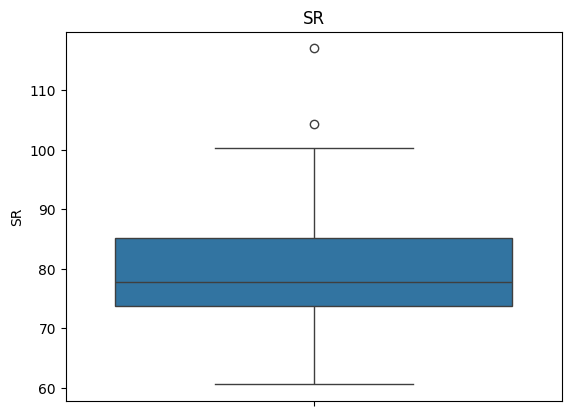

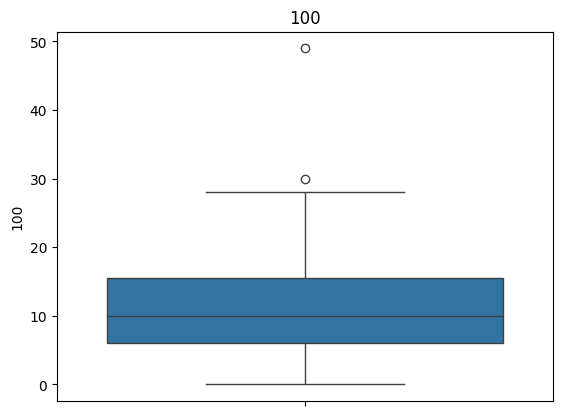

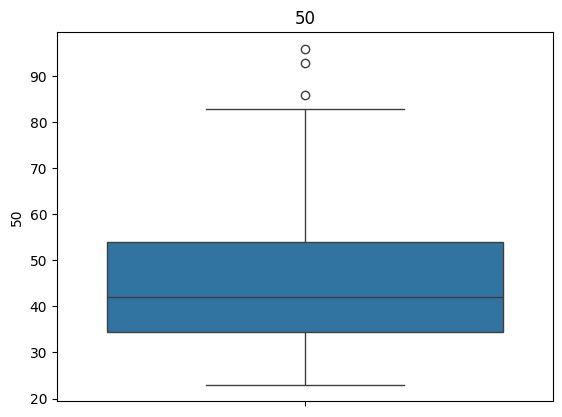

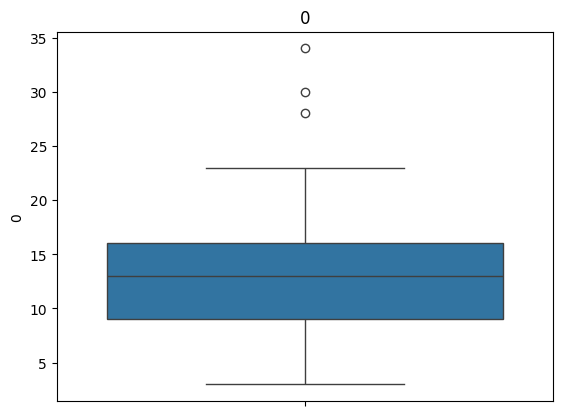

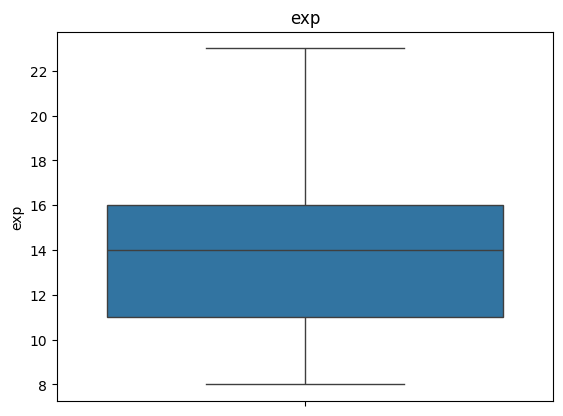

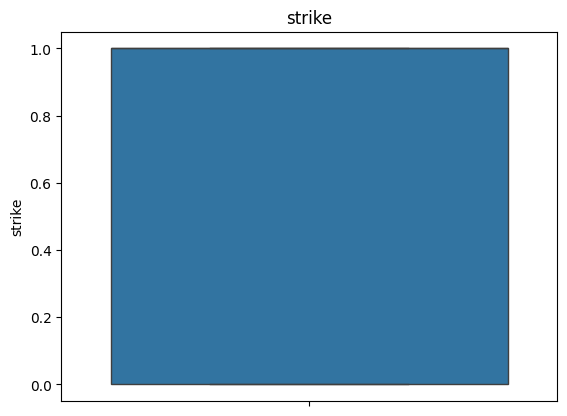

In [17]:
# Visulaizing the dataset to check is there any outliers

for col in df_copy.columns:
    if df_copy[col].dtype != 'object':
        sns.boxplot(df_copy[col])
        plt.title(col)
        plt.show()

In [18]:
# Removing the outliers by inter quartile range (IQR)

for col in df_copy:
    q1 = df_copy[col].quantile(0.25)  # calculating the 25th percetile
    q3 = df_copy[col].quantile(0.75)    # calculating the 75th percetile

    IQR = q3-q1 # Calculating the inter quartile range

    UB = q3+1.5*IQR 
    LB = q1-1.5*IQR

    df_copy = df_copy[(df_copy[col]>=LB) & (df_copy[col] <= UB)]

<Axes: >

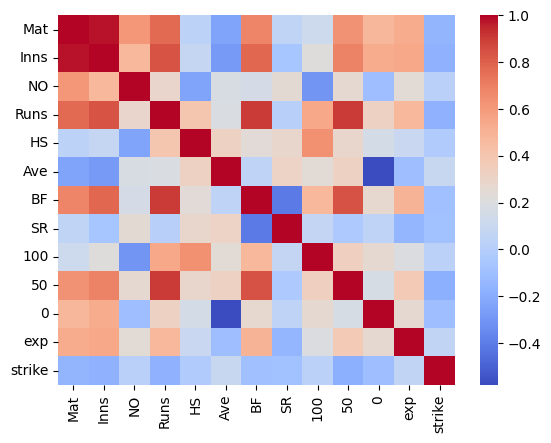

In [19]:
# Visulizing the correlation the features

sns.heatmap(df_copy.corr(), cmap='coolwarm')

In [20]:
# Normalizing the data set

from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
df_scaled = sc.fit_transform(df_copy)

df_scaled

array([[ 1.5865593 ,  1.83513966,  0.16611147,  2.60729994,  1.28071846,
         0.56871389,  2.09919921,  0.39288932,  2.27701556,  1.98007861,
         0.96062034,  1.22699509, -1.26131245],
       [ 1.35644765,  1.46770884,  0.73995111,  2.12575702,  0.05307482,
         0.82206585,  2.02809043, -0.18320931,  1.40300959,  2.07452588,
         0.72860611, -0.47882735,  0.79282497],
       [ 1.50288234,  1.05434917,  2.89184976,  1.96828897,  1.89454028,
         2.80150675,  0.92392904,  1.59211502,  0.31050212,  2.07452588,
        -0.89549354, -0.13766286,  0.79282497],
       [ 2.31873275,  2.27146376,  1.74417048,  1.88533705,  0.57920781,
        -0.16456494,  1.89328002, -0.32429469, -0.34500236,  1.50784229,
        -0.6634793 ,  0.54466611,  0.79282497],
       [ 1.77483247,  1.99589064,  0.02265156,  1.81925671,  0.22845248,
        -0.58063889,  1.28786774,  0.60451738,  0.52900361,  2.07452588,
         1.19263457,  1.90932406, -1.26131245],
       [ 0.49875875,  0.801740

In [21]:
df_scaled = pd.DataFrame(df_scaled,columns =df_copy.columns)

In [22]:
from sklearn.cluster import KMeans

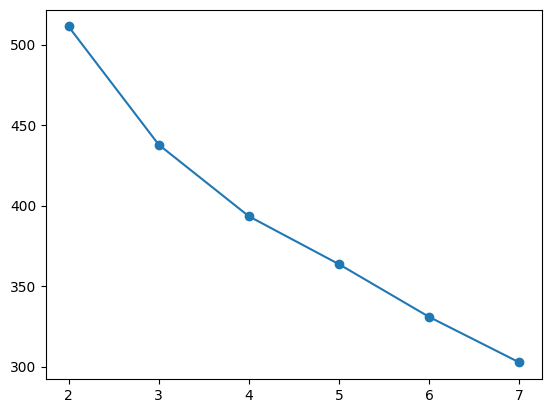

In [23]:
# To identify the no of cluster  using elbow method

cluster = [2,3,4,5,6,7]
ssd = []
for i in cluster:
    km = KMeans(n_clusters=i, random_state=150)
    km.fit(df_scaled)
    ssd.append(km.inertia_)
    
plt.plot(cluster, ssd, marker='o')

In [24]:
# Initiating the kmeans model with  4 cluster, and fit with data
km_model = KMeans(n_clusters=4, random_state=100)
km_model.fit(df_scaled)

KMeans(n_clusters=4, random_state=100)

In [25]:
# Storing the cluster values in data Frame.

df_copy['cluster'] = km_model.labels_

In [26]:
# Data Frame with cluster value

df_copy.head()

,Mat,Inns,NO,Runs,HS,Ave,BF,SR,100,50,0,exp,strike,cluster
9,299,289,32,10405,169,40.48,13086,79.51,19,63,16,17,0,1
11,288,273,40,9720,141,41.71,12942,75.10,15,64,15,12,1,1
13,295,255,70,9496,183,51.32,10706,88.69,10,64,8,13,1,1
14,334,308,54,9378,153,36.92,12669,74.02,7,58,9,15,1,1
16,308,296,30,9284,145,34.90,11443,81.13,11,64,17,19,0,1


In [27]:
# Cluster counts

df_copy.cluster.value_counts()

cluster
2    16
3    15
0    14
1    12
Name: count, dtype: int64